## Dependencias

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
import pandas as pd
import numpy as np
import json
from collections import Counter

# Data cleaning
import re
import unicodedata

# Multiprocessing
from multiprocessing import Pool

# Visualización
import stylecloud
from IPython.display import Image

# Text mining
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.feature_extraction.text import TfidfVectorizer

from IPython.display import Image
from stylecloud import gen_stylecloud
from tensorflow.keras.utils import plot_model

# Modelo
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV,KFold,StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler

# GRU
from keras import Model
from keras.layers import GRU, SpatialDropout1D, Bidirectional
from keras.layers import Input, GlobalAveragePooling1D, BatchNormalization,Dropout
from keras.layers import Dense
from sklearn.cluster import KMeans
from keras.layers import Embedding
from keras.layers import Activation
from keras.layers import concatenate
from tensorflow.keras.optimizers import Adam
from keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint

# Para las etiquetas
from sklearn.preprocessing import LabelEncoder


pd.set_option('display.max_columns', 200)

c:\Diplomado\diplo\Lib\site-packages\stylecloud\stylecloud.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [3]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[]


## Funciones

In [4]:
def clean_text(text, keep_twitter_tags=True):
    
    if not isinstance(text, str):
        return ""

    cleaned_text = text.lower()
    
    # Eliminamos los acentos pero nos quedamos con la ñ
    cleaned_text = ''.join(c for c in unicodedata.normalize('NFD', cleaned_text)
                           if unicodedata.category(c) != 'Mn')
    
    # Nos quedamos con las @, números, espacios, y #
    if keep_twitter_tags:
        pattern = r"[^a-zñ0-9@#]"
    else:
        pattern = r"[^a-zñ0-9 ]"
        
    cleaned_text = re.sub(pattern, " ", cleaned_text)
    
    cleaned_text = ' '.join(cleaned_text.split())
    
    return cleaned_text
    

def make_pool(func, params, threads):
    pool = Pool(threads)
    data = pool.map(func, params)
    pool.close()
    pool.join()
    del pool
    return data

def text_features(url, text):
    sid = SentimentIntensityAnalyzer()
    sentences = sent_tokenize(text)
    polarities = pd.DataFrame(map(sid.polarity_scores, sentences))
    words = pd.DataFrame(map(len, map(word_tokenize, sentences)))
    sentences_data = polarities.join(words).rename(columns={0: "n_words"})
    sentences_data["url"] = url
    return sentences_data

def get_wordcloud(text, icon="fas fa-comments", background_color=None, output_name="./wordcloud.png"):
    gen_stylecloud(text=text, icon_name=icon, background_color=background_color, output_name=output_name)
    return Image(filename=output_name)

def contador_palabras(df:pd.DataFrame, text_col:str, n_top:int):
    
    if df[text_col].dtype != 'O':
        print('El tipo de dato tiene que se string.')
        
    
    text_completo = ' '.join(df[text_col])
    
    palabras = text_completo.split()
    contador = Counter(palabras)
    
    top = contador.most_common(n_top)
    
    for palabra, frecuencia in top:
        print(f'{palabra}: {frecuencia}')

def vectorize_text(text, max_words, max_sequence_length):
    tokenizer = Tokenizer(num_words=max_words, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~', lower=True)
    tokenizer.fit_on_texts(text)
    word_index = tokenizer.word_index
    print('Found %s unique tokens.' % len(word_index))
    X = tokenizer.texts_to_sequences(text)
    X = pad_sequences(X, maxlen=max_sequence_length)
    return X, tokenizer

## Lectura de Datos

In [5]:
data_path = os.path.join(os.path.join(os.path.dirname(os.getcwd()),'datos'),'betsentiment-ES-tweets-sentiment-teams.csv')

In [6]:
df = pd.read_csv(data_path, encoding='latin1')
df.head()

,tweet_date_created,tweet_id,tweet_text,language,sentiment,sentiment_score
0,2018-08-08T13:09:15.489000,1027179935184703489,"Alisson puede estar más tranquilo, no cargará ...",es,POSITIVE,"{""Neutral"":0.082259356975555419921875,""Negativ..."
1,2018-08-08T18:27:37.320000,1027260056092344320,@iPincheViky @ChelseaFC Es que el director eje...,es,NEUTRAL,"{""Neutral"":0.827011644840240478515625,""Negativ..."
2,2018-08-12T14:59:31.520000,1028657238116843520,Upto £100 #freebets &gt; https://t.co/cbjeMXI9...,es,NEUTRAL,"{""Neutral"":0.930982112884521484375,""Negative"":..."
3,2018-08-04T13:23:30.257000,1025733971320160257,"Bobby Duncan, primo de Steven Gerrard, deja la...",es,NEUTRAL,"{""Neutral"":0.906872212886810302734375,""Negativ..."
4,2018-07-28T11:21:06.480000,1023166450981396480,@TorreiraForeva @lepvtron @Arsenal @IntChampio...,es,NEUTRAL,"{""Neutral"":0.942405760288238525390625,""Negativ..."


## Extraction & Data processing

In [7]:
scores_df = df['sentiment_score'].apply(json.loads).apply(pd.Series)

In [8]:
df_ = pd.concat([
    df.drop(columns=['sentiment_score']),
    scores_df
], axis=1)

df_.head()

,tweet_date_created,tweet_id,tweet_text,language,sentiment,Neutral,Negative,Positive,Mixed
0,2018-08-08T13:09:15.489000,1027179935184703489,"Alisson puede estar más tranquilo, no cargará ...",es,POSITIVE,0.082259,0.036536,0.745924,0.135281
1,2018-08-08T18:27:37.320000,1027260056092344320,@iPincheViky @ChelseaFC Es que el director eje...,es,NEUTRAL,0.827012,0.078550,0.071943,0.022495
2,2018-08-12T14:59:31.520000,1028657238116843520,Upto £100 #freebets &gt; https://t.co/cbjeMXI9...,es,NEUTRAL,0.930982,0.031428,0.030184,0.007406
3,2018-08-04T13:23:30.257000,1025733971320160257,"Bobby Duncan, primo de Steven Gerrard, deja la...",es,NEUTRAL,0.906872,0.057496,0.024875,0.010757
4,2018-07-28T11:21:06.480000,1023166450981396480,@TorreiraForeva @lepvtron @Arsenal @IntChampio...,es,NEUTRAL,0.942406,0.031377,0.020383,0.005833


In [9]:
# Observamos que tenemos clases desbalanceadas

df_['sentiment'].value_counts(True)

sentiment
NEUTRAL     0.838946
POSITIVE    0.082920
NEGATIVE    0.071503
MIXED       0.006631
Name: proportion, dtype: float64

## Ingeniería de Datos

In [10]:
df_['tweet_text'].isna().sum()

np.int64(0)

In [11]:
# Quitamos los urls

df_['tweet_text'] = df_['tweet_text'].map(lambda x: re.sub('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.#&+])+','', x ))

In [12]:
df_["len_tweet_text"] = df_['tweet_text'].str.len()
df_["n_words_tweet_text"] = df_['tweet_text'].str.split(" ").str.len()
df_["avg_len_words_tweet_text"] = df_['tweet_text'].str.split(" ").map(lambda x: np.mean([x for x in map(len, x)]))

In [13]:
contador_palabras(df_, 'tweet_text', 50)

El tipo de dato tiene que se string.
de: 104691
el: 82869
la: 61831
en: 61350
que: 51971
y: 51844
a: 48771
del: 38346
con: 26591
?: 26382
por: 26149
los: 23556
al: 23420
??: 22958
un: 21536
no: 21453
se: 21172
para: 20637
es: 19219
El: 18148
lo: 14527
su: 12719
@ChelseaFC: 12485
@LFC: 12368
-: 11892
@ManUtd: 11802
|: 10065
una: 9796
como: 8031
#PremierLeague: 7905
las: 7772
más: 7695
le: 7587
pero: 7561
@Arsenal: 7415
@Everton: 6955
equipo: 6899
partido: 6286
@ManCity: 6188
ha: 6172
vs: 5875
#Chelsea: 5824
#Arsenal: 5792
ya: 5738
jugador: 5732
si: 5587
este: 5102
me: 5091
@premierleague: 5011
@SpursOfficial: 4949


In [14]:
stop_words = stopwords.words('spanish')

In [15]:
stop_words = [clean_text(word) for word in stop_words]
df_['tweet_text'] = df_['tweet_text'].map(clean_text).map(lambda text: [word for word in text.split() if word not in stop_words]).str.join(' ')
df_['tweet_text']

0         alisson puede tranquilo cargara peso ser arque...
1         @ipincheviky @chelseafc director ejecutivo muj...
2         upto 100 #freebets gt #lol #gunners #matchedbe...
3         bobby duncan primo steven gerrard deja cantera...
4         @torreiraforeva @lepvtron @arsenal @intchampio...
                                ...                        
132702    apunta diario mirror #manchesterunited pensand...
132703    @andresmarocco @sscnapoli @d ospina1 @arsenal ...
132704    final partido @everton 1 vs @westhamespanol 3 ...
132705    amistoso champions liga city perra liverpool #...
132706    @raul jimenez9 estreno goleador @wolves victor...
Name: tweet_text, Length: 132707, dtype: object

In [16]:
df_.head(3)

,tweet_date_created,tweet_id,tweet_text,language,sentiment,Neutral,Negative,Positive,Mixed,len_tweet_text,n_words_tweet_text,avg_len_words_tweet_text
0,2018-08-08T13:09:15.489000,1027179935184703489,alisson puede tranquilo cargara peso ser arque...,es,POSITIVE,0.082259,0.036536,0.745924,0.135281,152,29,4.275862
1,2018-08-08T18:27:37.320000,1027260056092344320,@ipincheviky @chelseafc director ejecutivo muj...,es,NEUTRAL,0.827012,0.078550,0.071943,0.022495,80,11,6.363636
2,2018-08-12T14:59:31.520000,1028657238116843520,upto 100 #freebets gt #lol #gunners #matchedbe...,es,NEUTRAL,0.930982,0.031428,0.030184,0.007406,86,11,6.909091


In [17]:
# La clase esra desbalanceada

df_['sentiment'].value_counts(True)

sentiment
NEUTRAL     0.838946
POSITIVE    0.082920
NEGATIVE    0.071503
MIXED       0.006631
Name: proportion, dtype: float64

# Modelado XGBoost

In [18]:
num_palabras = df_['tweet_text'].str.lower().str.split().explode().nunique()

print(f'Hay {num_palabras} diferentes.')

Hay 100646 diferentes.


In [19]:
# Definición de variables

varc = ['len_tweet_text','n_words_tweet_text','avg_len_words_tweet_text']

txt_ = ['tweet_text']

um = ['tweet_id']

tgt = ['sentiment']

In [21]:
X = df_[txt_+varc].copy()

y = df_[tgt].copy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((106165, 8), (26542, 8), (106165, 1), (26542, 1))

In [ ]:
X_train.reset_index(drop=True, inplace=True), X_test.reset_index(drop=True, inplace=True), y_train.reset_index(drop=True, inplace=True), y_test.reset_index(drop=True, inplace=True)

(None, None, None, None)

### Label Encoder

In [ ]:
# Tratamos las etiqutas de la target

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train.values.ravel())

y_test_enc = le.transform(y_test.values.ravel())

### TF-IDF features

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    # min_df=0.001,
    # max_df=0.95,
    ngram_range=(1,2)
)

tfidf_train = pd.DataFrame(
    vectorizer.fit_transform(X_train[txt_[0]]).toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=X_train.index
)

tfidf_test = pd.DataFrame(
    vectorizer.transform(X_test[txt_[0]]).toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=X_test.index
)


In [ ]:
display(tfidf_train.head(2))
tfidf_train.shape

,00,00 am,00 hora,00 horas,00 hrs,00 hs,00 juegan,00 pm,000,000 000,000 firma,00h,00hrs,00hs,00pm,01,02,03,04,05,06,07,08,09,09 30,10,10 00,10 anos,10 millones,10 minutos,10 vs,100,100 100,100 freebets,100 futebol,100 millones,1000,100m,101,102,10m,11,11 00,11 30,11 anos,11 hs,11official,11official lfc,12,12 00,12 12,12 30,12 anos,12 puntos,120,12m,13,13 15,13 30,14,14 00,14 30,14 31,15,15 00,15 23,15 30,15 45,15 anos,15 millones,15 minutos,15 puntos,150,1524,15m,16,16 00,16 00hs,16 30,16 anos,1610hd,1612hd,1613,1613 hd,1613hd,16avos,16gb,16gb arsenal,16m,16titulosdeliga,16titulosdeliga andy,17,17 00,17 18,17 45,17 anos,17 smart,18,18 00,18 19,...,wolves mancity,wolves premierleague,wolves raul,wolves villarrealcf,wolves vs,wolves wolvesespanol,wolvesacademy,wolvesacademy wwfc,wolvesespanol,wolvesespanol everton,wolvesespanol raul,wolvesespanol wolves,wolvesespanol wolvesprt,wolvesprt,wolveswomen,woodward,world,worldcup,worldcup rusia2018,wow,ws,ws fichajes,wwfc,x17,x17 nemeziz,x18,x18 nemeziz,x2,xabialonso,xanesilveira,xd,xhaka,xherdan,xherdan shaqiri,xi,xi vs,xq,xs,xs 11official,yankees,yarmolenko,yaya,yaya toure,yb,yb manutd,yedlin,yendo,yerri,yerri mina,yerrimina,yerrlmina,yerry,yerry mina,yerrymina,yerrymina everton,yerrymina24,yessi,yessi prez,ynwa,ynwa lfc,ynwa premierleague,ynwa reds,york,yosoy8a,you,you ll,you never,young,young boys,youngboys,youngboys manchesterunited,youngboys manunited,your,youtube,youwillneverwalkalone,zabaleta,zabaletaaa,zabaletaaa ab23andrey,zabaletaaa cap,zaga,zaguero,zaha,zamponi,zappacosta,zarate,zaza,zeta,zidane,zinchenko,zinedine,zinedine zidane,zlatan,zola,zona,zonalibredehumo,zonalibredehumo noti90minutos,zouma,zuniga,zurda,zurdo
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


(106165, 10000)

### TAD

In [ ]:
X_train = pd.concat([X_train[varc], tfidf_train], axis=1)

In [ ]:
X_test = pd.concat([X_test[varc], tfidf_test], axis=1)

In [ ]:
X_train[varc].shape, tfidf_train.shape, X_train.shape

((106165, 7), (106165, 10000), (106165, 10007))

In [ ]:
display(X_train.head(3))
X_train.shape

,Neutral,Negative,Positive,Mixed,len_tweet_text,n_words_tweet_text,avg_len_words_tweet_text,00,00 am,00 hora,00 horas,00 hrs,00 hs,00 juegan,00 pm,000,000 000,000 firma,00h,00hrs,00hs,00pm,01,02,03,04,05,06,07,08,09,09 30,10,10 00,10 anos,10 millones,10 minutos,10 vs,100,100 100,100 freebets,100 futebol,100 millones,1000,100m,101,102,10m,11,11 00,11 30,11 anos,11 hs,11official,11official lfc,12,12 00,12 12,12 30,12 anos,12 puntos,120,12m,13,13 15,13 30,14,14 00,14 30,14 31,15,15 00,15 23,15 30,15 45,15 anos,15 millones,15 minutos,15 puntos,150,1524,15m,16,16 00,16 00hs,16 30,16 anos,1610hd,1612hd,1613,1613 hd,1613hd,16avos,16gb,16gb arsenal,16m,16titulosdeliga,16titulosdeliga andy,17,17 00,...,wolves mancity,wolves premierleague,wolves raul,wolves villarrealcf,wolves vs,wolves wolvesespanol,wolvesacademy,wolvesacademy wwfc,wolvesespanol,wolvesespanol everton,wolvesespanol raul,wolvesespanol wolves,wolvesespanol wolvesprt,wolvesprt,wolveswomen,woodward,world,worldcup,worldcup rusia2018,wow,ws,ws fichajes,wwfc,x17,x17 nemeziz,x18,x18 nemeziz,x2,xabialonso,xanesilveira,xd,xhaka,xherdan,xherdan shaqiri,xi,xi vs,xq,xs,xs 11official,yankees,yarmolenko,yaya,yaya toure,yb,yb manutd,yedlin,yendo,yerri,yerri mina,yerrimina,yerrlmina,yerry,yerry mina,yerrymina,yerrymina everton,yerrymina24,yessi,yessi prez,ynwa,ynwa lfc,ynwa premierleague,ynwa reds,york,yosoy8a,you,you ll,you never,young,young boys,youngboys,youngboys manchesterunited,youngboys manunited,your,youtube,youwillneverwalkalone,zabaleta,zabaletaaa,zabaletaaa ab23andrey,zabaletaaa cap,zaga,zaguero,zaha,zamponi,zappacosta,zarate,zaza,zeta,zidane,zinchenko,zinedine,zinedine zidane,zlatan,zola,zona,zonalibredehumo,zonalibredehumo noti90minutos,zouma,zuniga,zurda,zurdo
0,0.932408,0.003497,0.061138,0.002957,101,17,5.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.375281,0.107254,0.299830,0.217635,198,32,5.218750,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.585170,0.220609,0.185400,0.008821,239,43,4.581395,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.217923,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

(106165, 10007)

### Sample Weight

In [ ]:
weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

weights

array([0.29801538, 0.29801538, 0.29801538, ..., 3.49272931, 3.49272931,
       0.29801538], shape=(106165,))

### XGBoost Classifier

In [ ]:
xgb = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42
)

param_dist = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

grid_search = GridSearchCV(estimator=xgb,
                           param_grid=param_dist,
                           cv=5,
                           scoring='f1_macro',
                           n_jobs=-1)

### Entrenamiento

In [ ]:
grid_search.fit(X_train, y_train_enc, sample_weight=weights)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], ...}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


### Resultados

In [ ]:
print(f"Mejores Hiperparámetros:\n{grid_search.best_params_}")
print(f"Mejor F1 Macro (Validación): {grid_search.best_score_:.4f}")

Mejores Hiperparámetros:
{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.8}
Mejor ROC AUC (Validación): 0.9974


In [ ]:
y_pred = grid_search.predict(X_test)
y_pred_proba = grid_search.predict_proba(X_test)

In [ ]:
print("Rendimiento en TEST:")
print(f"F1 Macro Final: {f1_score(np.ravel(y_test_enc), y_pred, average='macro'):.4f}")
print(classification_report(np.ravel(y_test_enc), y_pred))

Rendimiento en TEST:
ROC AUC Final: 1.0000
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       190
           1       0.98      1.00      0.99      1890
           2       1.00      1.00      1.00     22274
           3       0.98      1.00      0.99      2188

    accuracy                           1.00     26542
   macro avg       0.97      1.00      0.98     26542
weighted avg       1.00      1.00      1.00     26542



### Guardamos el modelo

In [ ]:
import joblib

joblib.dump(grid_search.best_estimator_,'XGBClassifier_.pkl')

['XGBClassifier_.pkl']

# Modelado GRU

### Input Texto

In [22]:
X_text = X[txt_[0]]

In [23]:
content_max_words = 10000
content_max_sequence_length = 50

In [24]:
X_text_token, token_text = vectorize_text(
    X_text,
    content_max_words,
    content_max_sequence_length
)

Found 93740 unique tokens.


### Input Numérico

In [25]:
X_feat = X[varc].copy()

In [26]:
mm = MinMaxScaler()
X_feat_mm = mm.fit_transform(X_feat)
X_feat_mm

array([[0.18641975, 0.1314554 , 0.02582442],
       [0.09753086, 0.04694836, 0.0394998 ],
       [0.10493827, 0.04694836, 0.04307265],
       ...,
       [0.11481481, 0.05633803, 0.03913336],
       [0.08148148, 0.05164319, 0.02838428],
       [0.10864198, 0.06103286, 0.03337492]], shape=(132707, 3))

In [27]:
X_text.shape, X_text_token.shape, X_feat.shape

((132707,), (132707, 50), (132707, 3))

### Target

In [28]:
le_lst = LabelEncoder()

y_gru_enc = le_lst.fit_transform(y.values.ravel())

In [29]:
pd.DataFrame(y_gru_enc).value_counts( normalize=True)

0
2    0.838946
3    0.082920
1    0.071503
0    0.006631
Name: proportion, dtype: float64

## Arquitectura GRU

In [30]:
text_input = Input(
    shape=(content_max_sequence_length,), name='text_input'
)

x = Embedding(
    input_dim=content_max_words,
    output_dim=128,
    input_length=content_max_sequence_length,
    name='embedding_layer')(text_input)

x = SpatialDropout1D(0.3)(x)
x = Bidirectional(GRU(64, return_sequences=True, dropout=0.2,recurrent_dropout=0.2))(x)

text_features = GlobalAveragePooling1D()(x)

feat_input = Input(shape=(X_feat_mm.shape[1],),name='features_sequence')

feat_dense = Dense(64, activation='tanh')(feat_input)

concatenated = concatenate([
    text_features, feat_dense
], name='concatenation_layer')

z = Dense(64, activation='relu')(concatenated)
z = BatchNormalization()(z)
z = Dropout(0.4)(z)

outputs = Dense(4, activation='softmax',name='output_layer')(z)

model = Model(inputs=[text_input, feat_input], outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

c:\Diplomado\diplo\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [31]:
    model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_layer     │ (None, 50, 128)   │  1,280,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 50, 128)   │          0 │ embedding_layer[… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 50, 128)   │     74,496 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features_sequence   │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ bidirectional[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        256 │ features_sequenc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenation_layer │ (None, 192)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     12,352 │ concatenation_la… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 4)         │        260 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,367,620 (5.22 MB)

 Trainable params: 1,367,492 (5.22 MB)

 Non-trainable params: 128 (512.00 B)

In [32]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    min_delta=0.001,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'models_GRU/model_{val_loss:.3f}.keras',
    save_best_only=True,
    save_weights_only=False,
    mode='min',
    verbose=1
)

### Partición de Conjuntos


In [33]:
X_feat_train, X_feat_test, X_text_token_train, X_text_token_test, y_gru_train, y_gru_test = train_test_split(
    X_feat_mm,X_text_token,y_gru_enc, test_size=0.2, random_state=3
)

In [34]:
from sklearn.utils.class_weight import compute_class_weight

unique_classes = np.unique(y_gru_train)

weights_gru = compute_class_weight(
    'balanced',
    classes=unique_classes,
    y=y_gru_train
)

weights_gru_dict = dict(zip(unique_classes, weights_gru))

In [35]:
history = model.fit(
    {'text_input': X_text_token_train, 'features_sequence': X_feat_train},
    y_gru_train,
    validation_data=(
        {'text_input': X_text_token_test, 'features_sequence': X_feat_test},
        y_gru_test
    ),
    epochs=100,
    batch_size=32,
    class_weight=weights_gru_dict,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/100
3317/3318 ━━━━━━━━━━━━━━━━━━━━ 5:08:28 6s/step - accuracy: 0.1562 - loss: 1.43 ━━━━━━━━━━━━━━━━━━━━ 6:51 124ms/step - accuracy: 0.1406 - loss: 1.43 ━━━━━━━━━━━━━━━━━━━━ 3:36 65ms/step - accuracy: 0.1445 - loss: 1.3948 ━━━━━━━━━━━━━━━━━━━━ 3:47 69ms/step - accuracy: 0.1506 - loss: 1.398 ━━━━━━━━━━━━━━━━━━━━ 3:18 60ms/step - accuracy: 0.1605 - loss: 1.359 ━━━━━━━━━━━━━━━━━━━━ 3:13 59ms/step - accuracy: 0.1693 - loss: 1.321 ━━━━━━━━━━━━━━━━━━━━ 2:54 53ms/step - accuracy: 0.1775 - loss: 1.331 ━━━━━━━━━━━━━━━━━━━━ 2:41 49ms/step - accuracy: 0.1833 - loss: 1.356 ━━━━━━━━━━━━━━━━━━━━ 2:45 50ms/step - accuracy: 0.1860 - loss: 1.386 ━━━━━━━━━━━━━━━━━━━━ 2:38 48ms/step - accuracy: 0.1900 - loss: 1.434 ━━━━━━━━━━━━━━━━━━━━ 2:24 44ms/step - accuracy: 0.1937 - loss: 1.486 ━━━━━━━━━━━━━━━━━━━━ 2:18 42ms/step - accuracy: 0.1959 - loss: 1.539 ━━━━━━━━━━━━━━━━━━━━ 2:10 40ms/step - accuracy: 0.1988 - loss: 1.600 ━━━━━━━━━━━━━━━━━━━━ 2:03 37ms/step - accuracy: 0.2013 - loss: 1.641 ━━━━━━━━━━━

In [36]:
model.save('GRU_model_final.keras')

In [37]:
y_pred_gru = model.predict({'text_input': X_text_token_test, 'features_sequence': X_feat_test})

y_pred_classes = np.argmax(y_pred_gru, axis=1)



print(classification_report(y_gru_test, y_pred_classes, target_names=le_lst.classes_))

830/830 ━━━━━━━━━━━━━━━━━━━━ 9:29 687ms/st ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/st ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/st ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/st ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/st ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/ste ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/ste ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/ste ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/ste ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/ste ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/ste ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/ste ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/ste ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/ste ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/ste ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/ste ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/ste ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/ste ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/ste ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/ste ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/ste ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/ste ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/ste ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/ste ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/ste ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/ste ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/ste ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/s

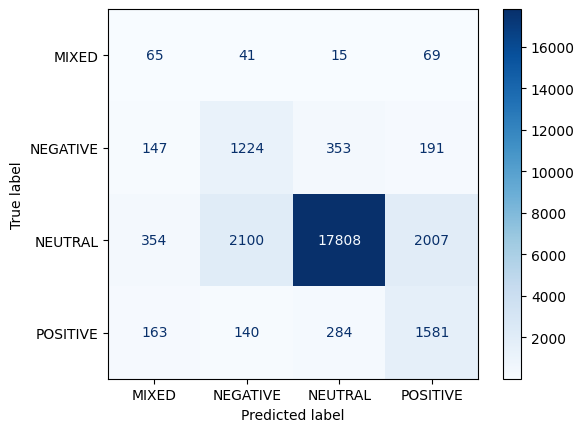

In [38]:
cn = confusion_matrix(y_gru_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cn, display_labels=le_lst.classes_)
disp.plot(cmap='Blues')
